# Wing Structure: Buckling, Materials, Manufacturing and Flutter
## MIE 446 - Independent visual lecture

**University of Massachusetts Amherst | Dr. Ehsan Roohi | Fall 2026**

How do thin skins, spars, ribs and stringers become a lightweight wing? Why can a strong material still buckle? What changed between the 7-Shi, 9-Shi and Zero? Why can a wing that passes a static-strength check still develop flutter?

This is a separate lecture, not a revision of Lecture 01. It connects the earlier force/load-path lessons to structural stability, manufacturing and dynamics. The figures and questions are visible before execution; run the short numerical cells only when you reach them. Save your own copy with **File > Save a copy in Drive**.

**Learning outcomes:** identify each member and its load path; distinguish strength, stiffness and stability; interpret a local displacement plot; explain the manufacturing/material tradeoffs; describe the energy condition for flutter; state what a simplified model cannot establish.

**Suggested teaching route:** meeting A - sections 1-5 (buckling, members, Wright and the printed wing); meeting B - sections 6-10 (Horikoshi, manufacturing, materials and flutter). Each block can be taught in about 60-75 minutes with selected calculations. Appendix material is optional.

**Safety and scope:** examples are educational, not airworthiness or print-release approvals. Do not load, crack, fly or test a student-built wing to failure. Follow the course project/TA safety rules. Historical military aircraft are studied as engineering evidence, not as an endorsement of their wartime use.

### Reading map

1. Buckling: what changes, and what does not?
2. The wing box and its members
3. Removing spars, ribs or stringers
4. Early wings: Chanute and the Wright brothers
5. Our printed wing and the seven-rib baseline
6. Horikoshi: 7-Shi, 9-Shi and Zero
7. Sheets, built-up spars and extrusion
8. Duralumin, age hardening and Extra Super Duralumin
9. Flutter: motion, airloads, phase and energy
10. Evidence, model limits and exit questions

## 1. Buckling is a loss of structural stability

Imagine pressing the ends of a thin ruler toward each other. At first it stays nearly straight. Beyond a critical load, a small sideways imperfection can grow into a much larger bend. This is **buckling**: the original equilibrium shape loses stability, or a real imperfect structure develops rapidly increasing lateral deformation.

A plate can do the same thing by wrinkling **out of its plane**. The material need not crack, melt or reach its yield stress for elastic buckling to occur. Under positive upward wing bending, upper skins/caps are commonly compressed while the lower region is in tension. Negative loading reverses this pattern.

Keep three questions separate:

| Property | Question | A representative quantity |
|---|---|---|
| Strength | How much stress can the material/component sustain? | Yield/ultimate stress; fatigue and fracture limits |
| Stiffness | How much does it deform under a load? | E, EI, torsional rigidity GJ |
| Stability | Does a small shape disturbance grow? | Buckling load/stress; aeroelastic stability boundary |

**Buckling is not necessarily final collapse.** Some stiffened panels are designed to carry additional load after local skin buckling; load redistributes toward stiffeners and adjacent effective skin. Other structures must remain unbuckled. The acceptable behavior depends on the design requirement, material, joints, imperfections and damage. [NASA's effective-width study](https://ntrs.nasa.gov/api/citations/20000109795/downloads/20000109795.pdf), introduction, printed p.1.

![Compression can produce lateral column bending or out-of-plane plate wrinkles. These schematic shapes are not cracks or calculated failure predictions.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Buckling_Column_and_Plate.png)

**Read the figure:** Compression can produce lateral column bending or out-of-plane plate wrinkles. These schematic shapes are not cracks or calculated failure predictions.

### 1A. A short, transparent column model

For a straight, slender, elastic column, Euler's ideal critical load is:
<p style="font-size:1.2em;color:#000;text-align:center">P<sub>cr</sub> = π² E I / (K L)²</p>

Here **E** is Young's modulus, **I** is the second moment of area about the buckling direction, **L** is the unsupported length, and **K L** is the effective length set by ideal end restraints. K = 1 for pinned-pinned, 2 for fixed-free, and 0.5 for fixed-fixed ideal columns.

For a rectangular strip bending through its thin dimension:
<p style="font-size:1.2em;color:#000;text-align:center">I = width × thickness³ / 12</p>

The cubic power explains why bending a thin sheet into a stiffener profile can help without simply adding a heavy solid slab. For unchanged E, I and end restraints, doubling unsupported length reduces Euler Pcr to one quarter. Do not apply this formula blindly to a short thick member, yielded material, an imperfect joint or a skin plate.

**Predict before calculating:** if the length doubles but the material stays the same, will buckling resistance double, halve, or fall to one quarter? Explain which term changes.

In [1]:
#@title Set up the short numerical activities
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.2})
print('Ready. The examples use idealized models, not measured wing properties.')

Ready. The examples use idealized models, not measured wing properties.


I = 8.3333e-13 m^4; EI = 0.058333 N m²; effective length KL = 0.400 m
Ideal Euler Pcr = 3.5983 N; axial stress at this load = 0.3598 MPa
With twice the length: 0.8996 N. This is onset, NOT final fracture load.


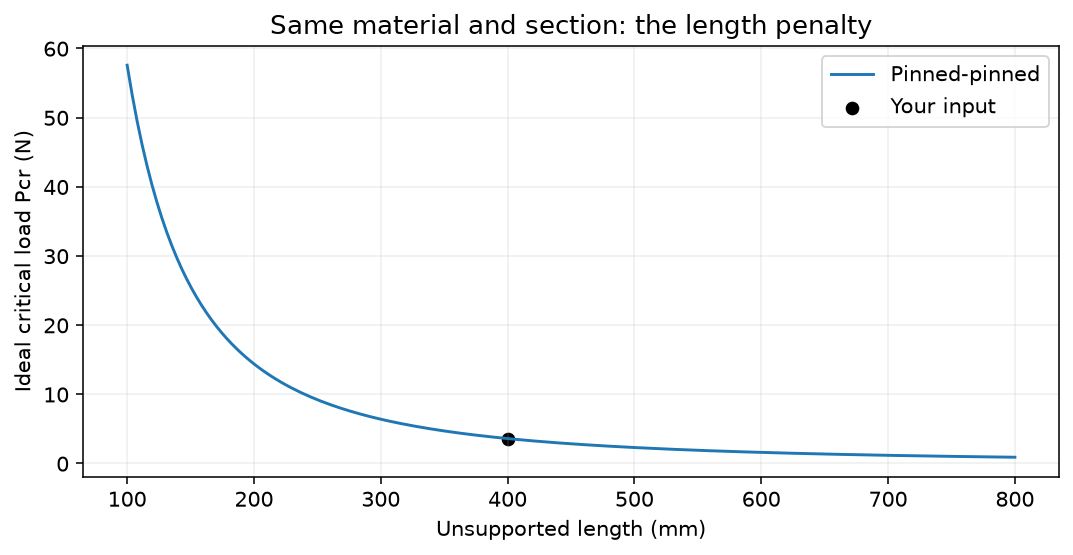

In [2]:
#@title Calculate an ideal strip-column buckling load
LENGTH_MM = 400.0 #@param {type:"number"}
WIDTH_MM = 10.0 #@param {type:"number"}
THICKNESS_MM = 1.0 #@param {type:"number"}
E_GPA = 70.0 #@param {type:"number"}
END_RESTRAINT = "Pinned-pinned" #@param ["Pinned-pinned", "Fixed-free", "Fixed-fixed"]
assert min(LENGTH_MM, WIDTH_MM, THICKNESS_MM, E_GPA) > 0, 'Use positive dimensions and modulus.'
K = {'Pinned-pinned': 1.0, 'Fixed-free': 2.0, 'Fixed-fixed': 0.5}[END_RESTRAINT]
L, width, thickness, E = LENGTH_MM/1000, WIDTH_MM/1000, THICKNESS_MM/1000, E_GPA*1e9
I = width*thickness**3/12
Pcr = np.pi**2*E*I/(K*L)**2
print(f'I = {I:.4e} m^4; EI = {E*I:.5g} N m²; effective length KL = {K*L:.3f} m')
print(f'Ideal Euler Pcr = {Pcr:.4f} N; axial stress at this load = {Pcr/(width*thickness)/1e6:.4f} MPa')
print(f'With twice the length: {Pcr/4:.4f} N. This is onset, NOT final fracture load.')
lengths = np.linspace(100, 800, 180)
plt.plot(lengths, np.pi**2*E*I/(K*lengths/1000)**2, label=END_RESTRAINT)
plt.scatter([LENGTH_MM], [Pcr], color='black', label='Your input')
plt.xlabel('Unsupported length (mm)'); plt.ylabel('Ideal critical load Pcr (N)')
plt.title('Same material and section: the length penalty'); plt.legend(); plt.show()

## 2. A wing is a connected load-carrying system

**Skin:** receives distributed aerodynamic pressure and transfers it through its attachments. In a stressed-skin wing it also carries membrane forces and torsional shear; it is not just a cover.

**Spar:** a major spanwise member. In the cap-and-web example, upper/lower caps resist bending-related axial forces, while the web carries shear. Skins and stringers can share bending loads too.

**Rib:** a mainly chordwise frame at a spanwise station. It maintains the section shape and provides connections, local load distribution and bracing according to the design.

**Stringer:** a smaller longitudinal stiffener attached to the skin. Wing stringers are commonly spanwise. They share axial load and reduce unsupported skin width; ribs can provide their intermediate restraint.

**Joints:** make the intended load transfer possible. A strong member with an inadequate attachment does not produce a strong wing.

These descriptions concern a conventional built-up architecture. Sandwich skins, integral stiffeners and composite designs can perform equivalent functions without every member appearing as a separate component. [FAA wing-structure explanation](https://www.faa.gov/lessons_learned/transport_airplane/accidents/grumman-turbo-mallard-g-73t), 'Wing Structure'.

![A section normal to the span, between ribs: upper/lower skins and front/rear spar webs form the closed wing-box perimeter. Stringers are attached to the inner skin surfaces; no rib lies in this particular cut.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Wing_Box_Section.png)

**Read the figure:** A section normal to the span, between ribs: upper/lower skins and front/rear spar webs form the closed wing-box perimeter. Stringers are attached to the inner skin surfaces; no rib lies in this particular cut.

![An exploded generic metal wing separates the upper skin, lower skin, two spars and chordwise ribs. This is not a recovered manufacturing drawing of a historical aircraft.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Metal_Wing_Skins_Exploded.png)

**Read the figure:** An exploded generic metal wing separates the upper skin, lower skin, two spars and chordwise ribs. This is not a recovered manufacturing drawing of a historical aircraft.

## 3. What changes when an existing member is removed?

In every comparison, keep the external load and remaining geometry unchanged. We are **removing a member from an existing design**, not engineering a replacement architecture.

### 3A. Remove a main spar

Load must find another path through the remaining skin, members and joints. Flexure and local demand can increase. Possible limits include compressive buckling, tensile cracking, excessive deformation or attachment failure; there is no universal first crack location.

For a cantilever under upward distributed load q(y), the bending moment at a cut is the sum of the outboard forces times their distances to that cut. Moving toward the root brings more loaded wing and longer lever arms into that sum. For a uniform q over semi-span L:
<p style="font-size:1.2em;color:#000;text-align:center">M(y) = q (L − y)² / 2; &nbsp; M<sub>root</sub> = q L² / 2</p>

This establishes a **root-moment maximum**, not a guaranteed root-stress or failure maximum. Local stress also depends on section geometry, strength, holes and joints. A reinforced root can survive while a weaker outboard detail fails.

![Side view of upward wing bending. The shaded root region highlights high bending demand, not a predicted fracture. Upper/lower spar caps are illustrated separately from the skin.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Wing_No_Spar_Possible_Failure.png)

**Read the figure:** Side view of upward wing bending. The shaded root region highlights high bending demand, not a predicted fracture. Upper/lower spar caps are illustrated separately from the skin.

### 3B. Remove intermediate ribs: use a side view, not ambiguous plan-view curves

The old plan-view sketch could make a red curve look like a stringer moving sideways across the skin. The following replacement looks **from the side** at one isolated slender stiffener strip. The horizontal axis is spanwise distance; the vertical axis is actual displacement in millimetres.

- **Blue dashed line:** the unloaded reference, z = 0. It is not another member.
- **Red curve:** the calculated loaded position of the ideal strip. Downward deflection is negative z.
- **Brown triangles:** ideal vertical supports supplied by ribs. The simplified supports allow rotation; they are not exact printed joints.
- **Black downward arrows:** the same local transverse load in both cases. This is an isolated local loading example, not the sign of the whole wing's net lift.

The example uses q = 2 N/m and EI = 0.20 N m². With ribs at 0, 150, 300 and 450 mm, each simple-support bay is 150 mm long. Removing the two intermediate supports leaves one 450 mm bay. For **this 1-D model only**, maximum displacement is:
<p style="font-size:1.2em;color:#000;text-align:center">w<sub>max</sub> = 5 q a⁴ / (384 E I)</p>

The result is **0.066 mm versus 5.339 mm**. The same axis scale is used in both plots, so the supported curve is almost flat. These are teaching-model numbers, not measured deflections of our wing.

**Important limitation:** an actual skin panel carries load in two in-plane directions. Its response depends on both rib spacing and chordwise support spacing, curvature and edge conditions. Do not use a fourth-power span-only rule to predict a rectangular skin plate. Rib removal may instead trigger section distortion, local plate instability or loss of stiffener bracing. A Boeing test paper documents premature wing-surface instability associated with inadequate rib strength. [NASA archive, 1962](https://ntrs.nasa.gov/citations/19630000940).

**Question:** does a nearly unchanged global tip deflection prove that ribs are unnecessary? No: a beam model can miss the local skin/section instability that ribs control.

![A common-scale side view makes the displacement direction and magnitude explicit. The red curve is a beam/strip displacement, not a crack and not a 2-D wing-skin buckling prediction.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Rib_Removal_Side_View.png)

**Read the figure:** A common-scale side view makes the displacement direction and magnitude explicit. The red curve is a beam/strip displacement, not a crack and not a 2-D wing-skin buckling prediction.

### 3C. Remove a stringer: the unsupported skin becomes wider

Removing a skin-attached stringer enlarges the chordwise panel width **b** between the remaining longitudinal supports. It also removes that member's contribution to axial stiffness and load carrying. The skin may wrinkle at a lower compressive demand; subsequent load redistribution depends on the remaining structure.

Keep the dimensions distinct: **a = spanwise distance between ribs; b = chordwise distance between stringers/supports; t = skin thickness.** The next formula is for a flat, isotropic, elastic plate with all four edges simply supported, under uniform spanwise compression, with no holes, curvature or damage:
<p style="font-size:1.2em;color:#000;text-align:center">σ<sub>cr</sub> = [k π² E / {12 (1 − ν²)}] (t / b)²</p>

E is modulus, ν is Poisson's ratio and k is a buckling coefficient that depends on aspect ratio and restraints. For a sufficiently long simply-supported panel k is close to 4. With unchanged k, doubling b reduces σcr to one quarter. **For a finite panel k can change too**, so we compute it rather than promise an exact factor in every geometry.

For this boundary/loading case, take the smallest coefficient over integer longitudinal half-wave counts m:
<p style="font-size:1.2em;color:#000;text-align:center">k = minimum of [m b/a + a/(m b)]², for m = 1, 2, 3, …</p>

This is a screening model. If elastic σcr exceeds yield stress, inelastic behavior must be checked. Printed PLA is not isotropic aluminium; layer orientation, joints, curvature and imperfections require other evidence.

![Compression acts along the span. Removing the central stringer doubles the unsupported chordwise width in this example. Red waves symbolize out-of-plane wrinkling, not a predicted crack pattern.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Wing_No_Stringers_Possible_Failure.png)

**Read the figure:** Compression acts along the span. Removing the central stringer doubles the unsupported chordwise width in this example. Red waves symbolize out-of-plane wrinkling, not a predicted crack pattern.

### Activity: separate rib spacing from stringer spacing

**Predict first:** which input changes a, which changes b, and which changes t? Will halving rib spacing always double the buckling stress? Why might a long plate remain near k = 4 for several different rib spacings?

Use the form below, then press Run to calculate. Change only one parameter at a time and explain the trend. Values represent an ideal aluminium teaching panel, not the released printed-wing design.

Selected panel: elastic σcr = 66.16 MPa; k = 4.000; longitudinal half-waves m = 3
Double stringer spacing b: elastic σcr = 17.95 MPa; k = 4.340; longitudinal half-waves m = 2
Half rib spacing a: elastic σcr = 71.79 MPa; k = 4.340; longitudinal half-waves m = 2
These are elastic onset values. Check yield, geometry, joints and imperfections separately.


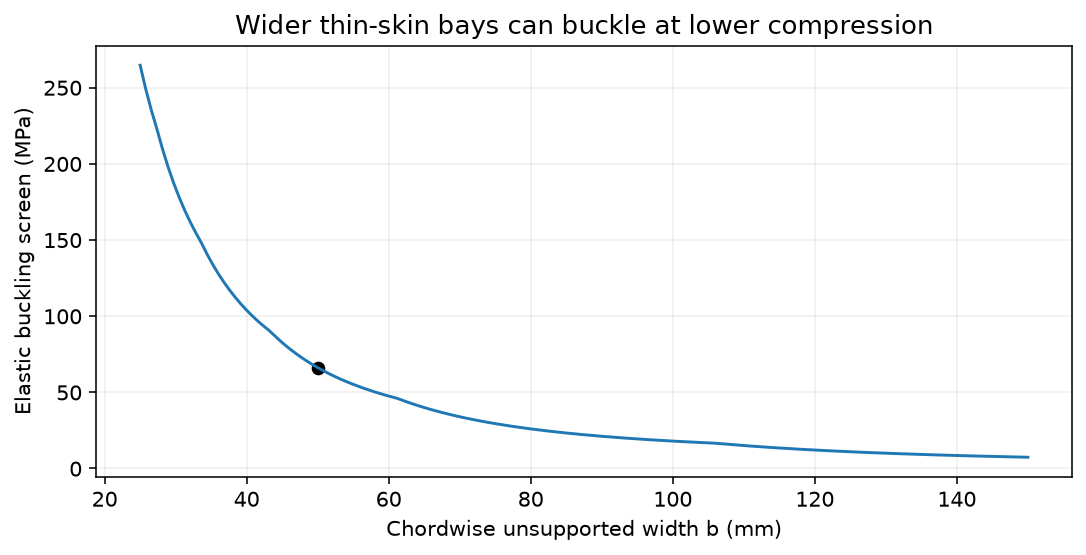

In [3]:
#@title Calculate a finite simply-supported plate buckling screen
RIB_SPACING_A_MM = 150.0 #@param {type:"number"}
STRINGER_SPACING_B_MM = 50.0 #@param {type:"number"}
SKIN_T_MM = 0.8 #@param {type:"number"}
PANEL_E_GPA = 70.0 #@param {type:"number"}
POISSON_NU = 0.33 #@param {type:"number"}
assert min(RIB_SPACING_A_MM, STRINGER_SPACING_B_MM, SKIN_T_MM, PANEL_E_GPA)>0
assert -1 < POISSON_NU < 0.5, 'Use an admissible isotropic Poisson ratio.'
def plate_screen(a_mm, b_mm, t_mm, e_gpa, nu):
    # Search around the analytic minimum m ~ a/b, avoiding a hard-coded mode ceiling.
    m = np.arange(1, max(3, int(np.ceil(a_mm/b_mm))+3))
    ks = (m*b_mm/a_mm + a_mm/(m*b_mm))**2
    index = int(np.argmin(ks)); k = float(ks[index])
    stress_mpa = k*np.pi**2*(e_gpa*1e9)/(12*(1-nu**2))*(t_mm/b_mm)**2/1e6
    return stress_mpa, k, int(m[index])
inputs=(RIB_SPACING_A_MM,STRINGER_SPACING_B_MM,SKIN_T_MM,PANEL_E_GPA,POISSON_NU)
baseline=plate_screen(*inputs)
wide=plate_screen(inputs[0],2*inputs[1],*inputs[2:])
closer=plate_screen(inputs[0]/2,*inputs[1:])
for label, result in [('Selected panel',baseline),('Double stringer spacing b',wide),('Half rib spacing a',closer)]:
    print(f'{label}: elastic σcr = {result[0]:.2f} MPa; k = {result[1]:.3f}; longitudinal half-waves m = {result[2]}')
print('These are elastic onset values. Check yield, geometry, joints and imperfections separately.')
widths=np.linspace(25,150,160)
stresses=[plate_screen(inputs[0],b,*inputs[2:])[0] for b in widths]
plt.plot(widths,stresses);plt.scatter([inputs[1]],[baseline[0]],color='black')
plt.xlabel('Chordwise unsupported width b (mm)');plt.ylabel('Elastic buckling screen (MPa)')
plt.title('Wider thin-skin bays can buckle at lower compression');plt.show()

## 4. Engineers did not discover the spar in one dramatic crash

There is no verified single aircraft or accident in these sources that marks the invention of the spar. Early aircraft builders already borrowed beam, frame and truss ideas from other structures. In 1896, Octave Chanute used a Pratt-truss arrangement related to his bridge-building experience. [US National Park Service](https://www.nps.gov/people/chanute.htm).

The Wright 1903 wing already had spanwise spars, chordwise ribs, fabric and an external bracing system. It was not a modern unbraced cantilever metal wing. The NASA image below is **a model with fabric removed**, not a photograph taken during the first flight. [NASA wing-geometry page](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/wing-geometry/).

For thin stressed-metal skins, the engineering question became how to prevent or safely accommodate instability without an excessive weight penalty. A documented analysis milestone is the application of the **effective-width concept to all-metal aircraft around 1932** by von Karman, Sechler and Donnell. This is not an invention date for stringers. [NASA technical report](https://ntrs.nasa.gov/api/citations/20000109795/downloads/20000109795.pdf).

![NASA photograph of a Wright 1903 wing model. Identify the long spars first, then the repeated ribs shaping the thin cambered section. Fabric and external bracing belong to the original aircraft architecture even though they are not all visible here.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Wright_1903_Wing.gif)

**Read the figure:** NASA photograph of a Wright 1903 wing model. Identify the long spars first, then the repeated ribs shaping the thin cambered section. Fabric and external bracing belong to the original aircraft architecture even though they are not all visible here.

## 5. Apply the ideas to our printed demonstrator

Our fabrication baseline has a **450 mm semi-span**, **three 150 mm modules**, a printed shell and rib/sleeve features, and two course-issued rods at x/c = 0.30 and 0.60. The rods are spanwise reinforcement; they are not automatically equivalent to conventional cap-and-web spars. Rod/sleeve load transfer depends on fit, attachment and assembly assumptions.

**There is no separate conventional array of T-shaped skin stringers in this baseline.** A rod near a skin does not become a skin-attached stringer simply because both run spanwise. Adding stringers would be a changed design requiring geometry, weight, printability and load-transfer checks.

Seven baseline ribs come from a **construction rule**, not a result that proves seven is structurally optimal:

- Three interior candidates: **112.5, 225 and 337.5 mm**.
- Paired ribs 4 mm either side of the two seams: **146, 154, 296 and 304 mm**.
- Sorted mid-plane stations: **112.5, 146, 154, 225, 296, 304, 337.5 mm**.

Root/tip end caps are separate and are not included in this count. Seam-support ribs do not themselves connect the modules. Other approved module/geometry settings can produce a different actual station list. Follow [PROJECT.md: why seven ribs](https://github.com/Ehsan-Roohi/Aerospace-Structures/blob/main/PROJECT.md#why-the-baseline-has-seven-ribs).

**Model-choice lesson:** a 1-D beam can explain global bending and tip deflection, but it cannot resolve every rib/skin local instability. The whole wing needs compatible global, local-panel, interface and manufacturing checks. Do not interpret a beam mesh node as a physical rib.

![Baseline plan view with all seven rib mid-planes, both module seams and both rod paths labelled. Closely paired seam ribs are deliberately separated in the label placement.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Printed_Wing_Seven_Ribs.png)

**Read the figure:** Baseline plan view with all seven rib mid-planes, both module seams and both rod paths labelled. Closely paired seam ribs are deliberately separated in the label placement.

## 6. Horikoshi: design knowledge, manufacturing capability and materials

Jiro Horikoshi studied aeronautical engineering at Tokyo Imperial University and joined Mitsubishi in 1927. An overseas industrial study tour in 1929-1930 exposed him to aircraft work in Europe and the United States. He worked within existing Japanese educational and industrial networks; he did **not single-handedly bring aviation to Japan**. Aircraft design was a team effort involving aerodynamicists, structural engineers, materials researchers, factory workers and test pilots.

Use the names carefully: **7-Shi** and **9-Shi** are prototype requirement labels associated with Showa years 7 and 9, not 'Seven C' or 'Nine C'. Mitsubishi's **1MF10** belongs to the 7-Shi project; **Ka-14** belongs to the 9-Shi project; the production **A5M/Type 96** evolved from Ka-14. **A6M/Type Zero** is a later family, not another name for Ka-14.

The short construction facts below are grounded in [Hideo Yoshida's National Museum of Nature and Science survey](https://sts.kahaku.go.jp/albums/abm.php?d=6689&f=abm00010625.pdf&n=130_e.pdf), chapter 8, printed pp.77-82. Keep prototype and production configurations separate.

![Historical photograph of Horikoshi, October 1938. Unknown photographer; Commons marks the photo public domain in Japan and the United States. Portraits identify a person, not a construction detail.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Horikoshi_1938.jpg)

**Read the figure:** Historical photograph of Horikoshi, October 1938. Unknown photographer; Commons marks the photo public domain in Japan and the United States. Portraits identify a person, not a construction detail.

### 6A. 7-Shi / Mitsubishi 1MF10: built-up construction

The 1932 project used a metal wing framework with **fabric covering**. Suitable large duralumin extrusions were not readily available, so thin sheets were assembled and riveted into the spars. The design had comparatively thick wings and did not meet its speed objective. These documented construction facts do not by themselves diagnose its accidents.

**Structural interpretation:** a built-up spar can be effective, but its flanges, web and fasteners all require space and reliable load transfer. The problem is not 'there was no spar'; the design had spars. The drawing in section 7 illustrates the fabrication concept, not an exact recovered 1MF10 cross-section.

![Historical 1MF10/7-Shi photograph (400 × 149 pixels). Notice the thick wing and fixed landing gear; the exterior does not reveal the spar section. Unknown photographer; Commons PD tags and limited original provenance are recorded in the asset credits.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Mitsubishi_1MF10.jpg)

**Read the figure:** Historical 1MF10/7-Shi photograph (400 × 149 pixels). Notice the thick wing and fixed landing gear; the exterior does not reveal the spar section. Unknown photographer; Commons PD tags and limited original provenance are recorded in the asset credits.

### 6B. 9-Shi / Ka-14 and the production A5M: a different structural package

The 9-Shi development used a thinner all-metal wing, metal skin and extruded spar-flange sections. Its first prototype had an inverted-gull wing; the production A5M was not geometrically identical.

**Alloy caveat:** the museum survey explicitly discusses uncertainty about the precise alloy of the earliest Ka-14 extrusions. Do not label every first-prototype flange '2024' or 'ESD'. Manufacturing form is documented more confidently than that exact early alloy identification.

**Why this can help a thin wing:** useful cap area can be put into a compact profile; structural metal skin shares load. But reduced wing depth also reduces the bending lever arm. Thinness is not a free structural improvement: strength, stiffness, stability, attachments and aerodynamic benefits must be balanced.

![First Ka-14 prototype with an inverted-gull wing. This historical photograph is not a production-A5M drawing. Unknown photographer; Commons marks it public domain; original provenance is recorded.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Ka14_First_Prototype.jpg)

**Read the figure:** First Ka-14 prototype with an inverted-gull wing. This historical photograph is not a production-A5M drawing. Unknown photographer; Commons marks it public domain; original provenance is recorded.

### 6C. Zero: stronger caps were one part of a lightweight design

The Zero project began in 1937; its prototype first flew in 1939 and the type entered service in 1940. The museum survey identifies **T-shaped ESD extrusions for spar caps** and distinguishes these from the sheet web. It reports that SDC/24S clad sheet was used for much of the web material rather than assuming all parts were ESD.

**Do not say:** 'The entire spar was extruded in one piece' or 'every part of the Zero skin was made of the strongest alloy'. Product form, local material and component function are distinct choices.

The Smithsonian describes other weight-saving details, including lightening holes and integrated assembly choices. Those choices also affect manufacturing effort, maintainability, damage tolerance and protection. [Smithsonian engineering discussion](https://airandspace.si.edu/stories/editorial/mitsubishi-a6m-zero-fighter).

![Smithsonian A6M5 Model 52, photographed by Eric Long; CC0. This surviving later model is not the 1939 A6M1 prototype and does not establish the material of every hidden member.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Zero_A6M5_Museum.jpg)

**Read the figure:** Smithsonian A6M5 Model 52, photographed by Eric Long; CC0. This surviving later model is not the 1939 A6M1 prototype and does not establish the material of every hidden member.

## 7. What exactly is extruded?

An **extrusion** is made by pushing a heated solid billet through a shaped die. The emerging product is a long member with an approximately constant cross-section. It is not molten metal being poured through a hole.

In a built-up spar, separate sheet/angle parts are formed and connected. In the later example, **caps/flanges can be extruded while the web remains a separate sheet**. The whole assembly still needs joining, machining, inspection and protective treatment. A longer profile can be trimmed or machined to vary its area along the span; a constant-section extrusion is only the starting product.

The left section below is a generic built-up concept. The right uses the museum's described Zero cap/web arrangement as the basis for an explanatory redraw. It must not be used as a shop drawing for either prototype. The museum also records installation of a large extrusion press in 1935; that date is not a claim that extrusion itself was invented then.

![Compare riveted sheet-built caps with extruded caps joined to a separate web. The historical comparison is schematic; the early 9-Shi alloy remains qualified in the text.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Spar_Built_Up_vs_Extruded.png)

**Read the figure:** Compare riveted sheet-built caps with extruded caps joined to a separate web. The historical comparison is schematic; the early 9-Shi alloy remains qualified in the text.

![Ram → heated solid billet → shaped die → long profile. The front view of the die shows how a T-shaped opening defines the emerging section; alloy-specific processing temperatures are not prescribed.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Aluminum_Extrusion_Process.png)

**Read the figure:** Ram → heated solid billet → shaped die → long profile. The front view of the die shows how a T-shaped opening defines the emerging section; alloy-specific processing temperatures are not prescribed.

![The skin starts as rolled sheet, is shaped to the wing contour and attached to underlying structure. The enlarged joint distinguishes the skin, cap, web and fasteners; it is not a historical airframe joint specification.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Skin_Forming_and_Spar_Joint.png)

**Read the figure:** The skin starts as rolled sheet, is shaped to the wing contour and attached to underlying structure. The enlarged joint distinguishes the skin, cap, web and fasteners; it is not a historical airframe joint specification.

### 7A. Why a thinner wing can be harder structurally

For an ideal two-cap spar with cap centroids separated by h, equal area A in each cap, and bending moment M:
<p style="font-size:1.2em;color:#000;text-align:center">Cap force magnitude ≈ M/h; &nbsp; cap stress magnitude ≈ M/(A h)</p><p style="font-size:1.2em;color:#000;text-align:center">I ≈ A h²/2; &nbsp; bending rigidity = E I</p>

Reducing h requires larger cap force for the same M. For unchanged A, reducing h also reduces EI strongly. A higher-strength alloy may allow smaller A for a **strength-limited** design, but if E remains similar, the smaller section is less stiff. Buckling, torsion, fatigue and joints can govern before that attractive weight saving is usable.

**Predict:** can substituting a stronger aluminium alloy, with nearly the same E, make an unchanged spar bend substantially less? Which property would actually have to change?

In [4]:
#@title Compare cap stress and stiffness when wing depth changes
MOMENT_NM = 400.0 #@param {type:"number"}
CAP_AREA_EACH_MM2 = 100.0 #@param {type:"number"}
CAP_SEPARATION_MM = 80.0 #@param {type:"number"}
SPAR_E_GPA = 70.0 #@param {type:"number"}
assert CAP_AREA_EACH_MM2>0 and CAP_SEPARATION_MM>0 and SPAR_E_GPA>0
A=CAP_AREA_EACH_MM2*1e-6; h=CAP_SEPARATION_MM*1e-3; Ecap=SPAR_E_GPA*1e9
for label, depth in [('Selected depth',h),('25% smaller depth',.75*h)]:
    Icap=A*depth**2/2
    print(f'{label}: cap force = {abs(MOMENT_NM)/depth:.1f} N; stress = {abs(MOMENT_NM)/(A*depth)/1e6:.2f} MPa; EI = {Ecap*Icap:.1f} N m²')
print('25% smaller depth: cap stress ×(1/0.75) = 1.333; EI ×0.75² = 0.5625.')
print('Cap-only model: web/skin stiffness, local buckling, joints and torsion are not included.')

Selected depth: cap force = 5000.0 N; stress = 50.00 MPa; EI = 22400.0 N m²
25% smaller depth: cap force = 6666.7 N; stress = 66.67 MPa; EI = 12600.0 N m²
25% smaller depth: cap stress ×(1/0.75) = 1.333; EI ×0.75² = 0.5625.
Cap-only model: web/skin stiffness, local buckling, joints and torsion are not included.


## 8. Duralumin is an aluminium alloy, not a different base metal

**Duralumin:** an early age-hardenable aluminium alloy family principally involving copper and magnesium, with other additions depending on grade.

**Super Duralumin:** stronger historical variants; the label was not a unique modern specification. Historical Japanese grades changed with time, so names alone do not prove identical chemistry.

**Extra Super Duralumin (ESD):** an Al-Zn-Mg-Cu alloy developed by Isamu Igarashi and colleagues at Sumitomo in the mid-1930s. Minor additions and processing mattered, including work on stress-corrosion cracking. It was an important predecessor/relative of later 7075 development, not proof of exact interchangeability with every modern 7075 temper. [Yoshida, 2023](https://www.jstage.jst.go.jp/article/matertrans/64/2/64_MT-LA2022019/_html/-char/en); [manufacturer history](https://www.uacj.co.jp/english/company/history/story01.html).

**Where did Zero's material come from?** This was collaboration between Mitsubishi's aircraft designers and Sumitomo's metallurgy/manufacturing team, under aircraft requirements. An actual [Igarashi-Kitahara 1939 paper](https://doi.org/10.14822/jjsass1934.6.53_982) reports ESD/ESDC material properties and is a contemporary source, not a film account.

**Age hardening:** solution treatment dissolves more solute into the solid matrix; a rapid quench retains a supersaturated state; controlled aging produces fine clusters/precipitates that impede dislocation motion. Exact phases, temperatures and times depend on alloy and temper. This explains higher resistance to plastic flow, not a proportional increase in Young's modulus.

![A schematic atomic-scale explanation: fine obstacles impede dislocation motion. This is not a micrograph or a heat-treatment recipe, and it does not imply that stronger material has proportionally higher elastic stiffness.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Duralumin_Age_Hardening.png)

**Read the figure:** A schematic atomic-scale explanation: fine obstacles impede dislocation motion. This is not a micrograph or a heat-treatment recipe, and it does not imply that stronger material has proportionally higher elastic stiffness.

### 8A. Strength is not the only material requirement

**Stress-corrosion cracking** is cracking produced by susceptible material exposed to a relevant environment while under tensile stress. Stress may be applied or residual. It is not the same as ordinary surface corrosion, and it is not automatically solved by high tensile strength.

A structural material decision also needs stiffness, fatigue/fracture behavior, toughness, environmental resistance, product form, heat-treatment consistency, joints and inspection. Protective cladding adds a more corrosion-resistant surface layer to a sheet; it does not mean the complete thickness is that protective alloy.

Compare choices in this order: **load and boundary conditions → geometry → alloy and temper → manufacturing/joints → stability and durability → evidence**. For printed PLA, layer adhesion, anisotropy, temperature and time-dependent deformation require separate checks; metal-alloy history is not a PLA material card.

## 9. Flutter is an aeroelastic dynamic instability

Buckling concerns stability of a loaded structural shape. **Flutter** concerns stability of motion in airflow. A moving, flexible wing changes its aerodynamic loading; the loading changes the motion. Feedback exists even below the flutter boundary: it becomes unstable only when its timing and strength supply more vibration energy than the structure dissipates.

Read the sequence:

1. A disturbance produces bending h(t), twisting θ(t), or control-surface motion.
2. Twist changes local incidence; vertical velocity changes the relative flow direction too.
3. The unsteady lift and moment change, with timing/phase determined by flow and motion.
4. Those loads act on the flexible structure again.
5. If net energy input per cycle is positive near the mode, amplitude can grow.

This is **not simply 'lift increases, so the wing vibrates'**, and it is not necessarily ordinary forced resonance. A wing can meet static strength requirements while having an unacceptable flutter boundary.

![The upper diagram links section motion to unsteady airloads. The lower envelopes distinguish decay, neutral linear onset and growth. Curves are illustrative; they do not calculate an actual flutter speed.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Flutter_Mechanism.png)

**Read the figure:** The upper diagram links section motion to unsteady airloads. The lower envelopes distinguish decay, neutral linear onset and growth. Curves are illustrative; they do not calculate an actual flutter speed.

### 9A. The equations, in readable form

A simplified coupled bending/torsion model has the form:
<p style="font-size:1.2em;color:#000;text-align:center">M q̈ + C q̇ + K q = F<sub>aero</sub>(q, q̇, flow history, V) + B δ</p>

q is a vector of generalized bending/twist coordinates; M, C and K are mass, damping and stiffness matrices; V is airspeed; δ is a control input. Off-diagonal terms and unsteady aerodynamics can couple modes. This lecture explains the mechanism; it does not identify these matrices for our wing.

For one bending coordinate, aerodynamic work per cycle is:
<p style="font-size:1.2em;color:#000;text-align:center">W<sub>aero</sub> = ∮ L dh; &nbsp; net cycle energy = W<sub>aero</sub> − energy dissipated</p>

For the simple harmonic example h = A sin(ωt) and L = F sin(ωt + φ):
<p style="font-size:1.2em;color:#000;text-align:center">W<sub>aero</sub> = π F A sin φ</p>

Derivation in words: multiply force by velocity dh/dt = Aω cos(ωt), then integrate over one period. The sin×cos term averages to zero and cos² contributes half a period. Positive work adds energy; negative work removes it. **This force history is prescribed, not calculated from an aerodynamic model.**

**Predict:** when φ = 90°, is the force in phase with displacement or velocity? Does it add or remove energy? When φ = −90°, what changes?

Aerodynamic work = 3.1416 mJ/cycle; independent numerical integral = 3.1416 mJ/cycle
Net cycle energy at the selected amplitude = 1.1416 mJ
Energy is added.
Prescribed harmonic forces: this result is NOT a real-wing flutter prediction.


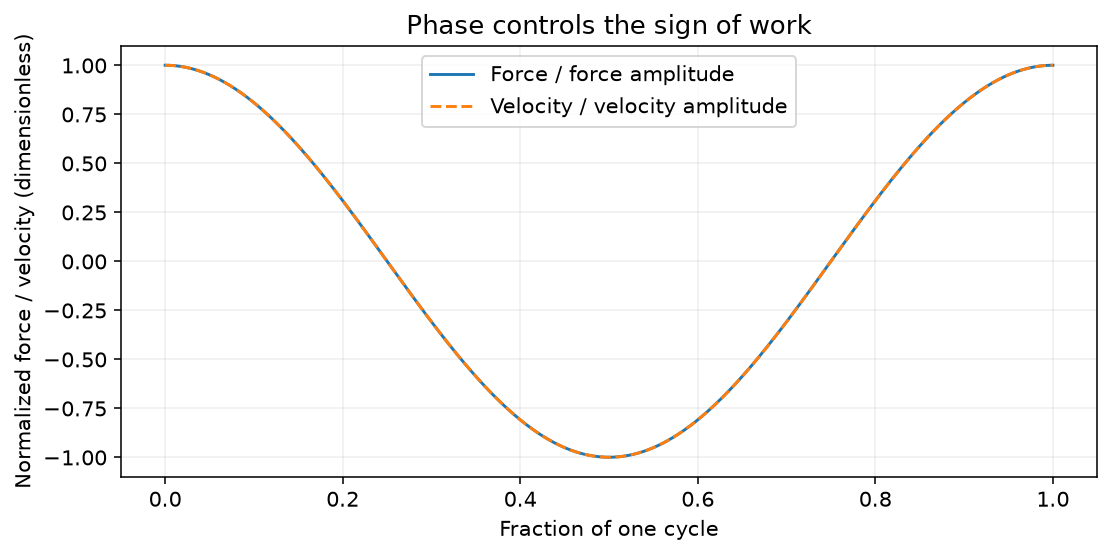

In [5]:
#@title Check aerodynamic work and phase in the prescribed-force example
PHASE_DEG = 90.0 #@param {type:"number"}
FORCE_AMPLITUDE_N = 0.2 #@param {type:"number"}
DISPLACEMENT_AMPLITUDE_MM = 5.0 #@param {type:"number"}
ENERGY_DISSIPATED_PER_CYCLE_MJ = 2.0 #@param {type:"number"}
assert min(FORCE_AMPLITUDE_N, DISPLACEMENT_AMPLITUDE_MM)>0
assert ENERGY_DISSIPATED_PER_CYCLE_MJ>=0
phi=np.deg2rad(PHASE_DEG); A=DISPLACEMENT_AMPLITUDE_MM/1000; F=FORCE_AMPLITUDE_N
phase=np.linspace(0,2*np.pi,4001)
force=F*np.sin(phase+phi); hdot_over_omega=A*np.cos(phase)
integrate=getattr(np,'trapezoid',None) or np.trapz
numerical_work=integrate(force*hdot_over_omega,phase)
exact_work=np.pi*F*A*np.sin(phi)
assert np.isclose(numerical_work,exact_work,atol=1e-12)
net_mj=exact_work*1000-ENERGY_DISSIPATED_PER_CYCLE_MJ
print(f'Aerodynamic work = {exact_work*1000:.4f} mJ/cycle; independent numerical integral = {numerical_work*1000:.4f} mJ/cycle')
print(f'Net cycle energy at the selected amplitude = {net_mj:.4f} mJ')
print('Energy is added.' if net_mj>1e-8 else 'Energy is removed.' if net_mj < -1e-8 else 'Energy is balanced at this amplitude.')
print('Prescribed harmonic forces: this result is NOT a real-wing flutter prediction.')
plt.plot(phase/(2*np.pi),force/F,label='Force / force amplitude')
plt.plot(phase/(2*np.pi),np.cos(phase),'--',label='Velocity / velocity amplitude')
plt.xlabel('Fraction of one cycle');plt.ylabel('Normalized force / velocity (dimensionless)')
plt.title('Phase controls the sign of work');plt.legend();plt.show()

### 9B. Why flutter does not require approaching the speed of sound

The flutter boundary depends on the coupled system: mass distribution, stiffness, damping, attachments, control-surface balance and unsteady aerodynamics. It is not a universal Mach number and cannot be diagnosed from speed alone. For a concrete subsonic research example, NASA's [AePW3 large-deflection benchmark](https://nescacademy.nasa.gov/workshops/AePW3/public/wg/largedeflection) reports flutter at 43 m/s and 5° angle of attack for its specific flexible model. That is not a transferable safe speed for another wing.

At fixed density and aerodynamic coefficients, pressure and load scale with speed squared:
<p style="font-size:1.2em;color:#000;text-align:center">Dynamic pressure q<sub>dyn</sub> = ½ ρ V²</p>

But a larger static load is not itself a flutter diagnosis. Near sonic conditions, shock-related effects and buffet can add different problems; subsonic flutter is already possible without them.

Keep neighboring concepts distinct: **divergence** is a static aeroelastic twisting instability; **control reversal** is a change/loss of intended control effectiveness due to flexibility; **flutter** is an oscillatory dynamic instability.

### 9C. The film, the historical projects and a documented accident are different evidence

*The Wind Rises* is a fictionalized film, not an accident investigation. A depicted wing vibration/breakup is a useful prompt to discuss aeroelasticity; it does not prove the initiating mechanism, alloy or exact aircraft configuration. Do not claim that 7-Shi lacked a spar or that an animated scene proves ESD was defective. [Studio Ghibli film record](https://www.ghibli.jp/works/kazetachinu/).

A separate documented event discussed in the museum survey is the **11 March 1940 breakup of the second Zero prototype**. It reports fatigue of an elevator mass-balance arm, loss of balance and subsequent tail flutter; suspected ESD spar problems were investigated rather than simply assumed to be the cause. This is a tail/control-system sequence, **not a verified diagnosis of the earlier animated scene**. [Museum survey, printed p.81](https://sts.kahaku.go.jp/albums/abm.php?d=6689&f=abm00010625.pdf&n=130_e.pdf).

**Structural lesson:** failure of a small balance attachment can change the dynamics of the whole aircraft. Stronger spar material does not repair a missing balance mass or inadequate control-surface attachment.

### 9D. What does NASA's controller do?

Sensors measure response; the controller commands fast, appropriately phased control-surface motion; the resulting aerodynamic force/moment can oppose motion and remove oscillation energy. It does not eliminate airflow or simply 'hold the wing rigid'. Mistimed commands, delays or actuator limits can reduce the benefit or destabilize the system.

NASA/Boeing's Integrated Adaptive Wing Technology Maturation tests used a scaled model with **ten trailing-edge control surfaces**, studying gust-load alleviation, maneuver loads and flutter suppression. Gust reduction and flutter suppression are related control goals but are not identical tests. [NASA source and video](https://www.nasa.gov/aeronautics/nasa-boeing-test-aircraft-wings/).

[Watch the NASA video](https://www.youtube.com/watch?v=TJNJfrkge9o). After watching, identify the sensors, actuated surfaces and response being reduced. A dramatic reduction in visible shaking alone does not establish every stability margin.

![NASA/Mark Knopp photograph of the scaled adaptive-wing model in the Transonic Dynamics Tunnel. Read it together with the official description of its ten trailing-edge control surfaces; not every actuator is distinguishable in this single photograph.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/NASA_Adaptive_Wing.png)

**Read the figure:** NASA/Mark Knopp photograph of the scaled adaptive-wing model in the Transonic Dynamics Tunnel. Read it together with the official description of its ten trailing-edge control surfaces; not every actuator is distinguishable in this single photograph.

### Activity: read a stability envelope

For a single ideal oscillator, ẍ + 2ζωn ẋ + ωn² x = 0. Positive effective damping gives decay; zero gives neutral linear motion; negative gives growth. The next plot is a **damping surrogate**, not an identified aerodynamic/structural wing model. Its frequency is illustrative and no speed is mapped to ζ.

**Question:** can an undamped natural-frequency calculation alone tell you whether the air supplies or removes energy? Explain what information is missing.

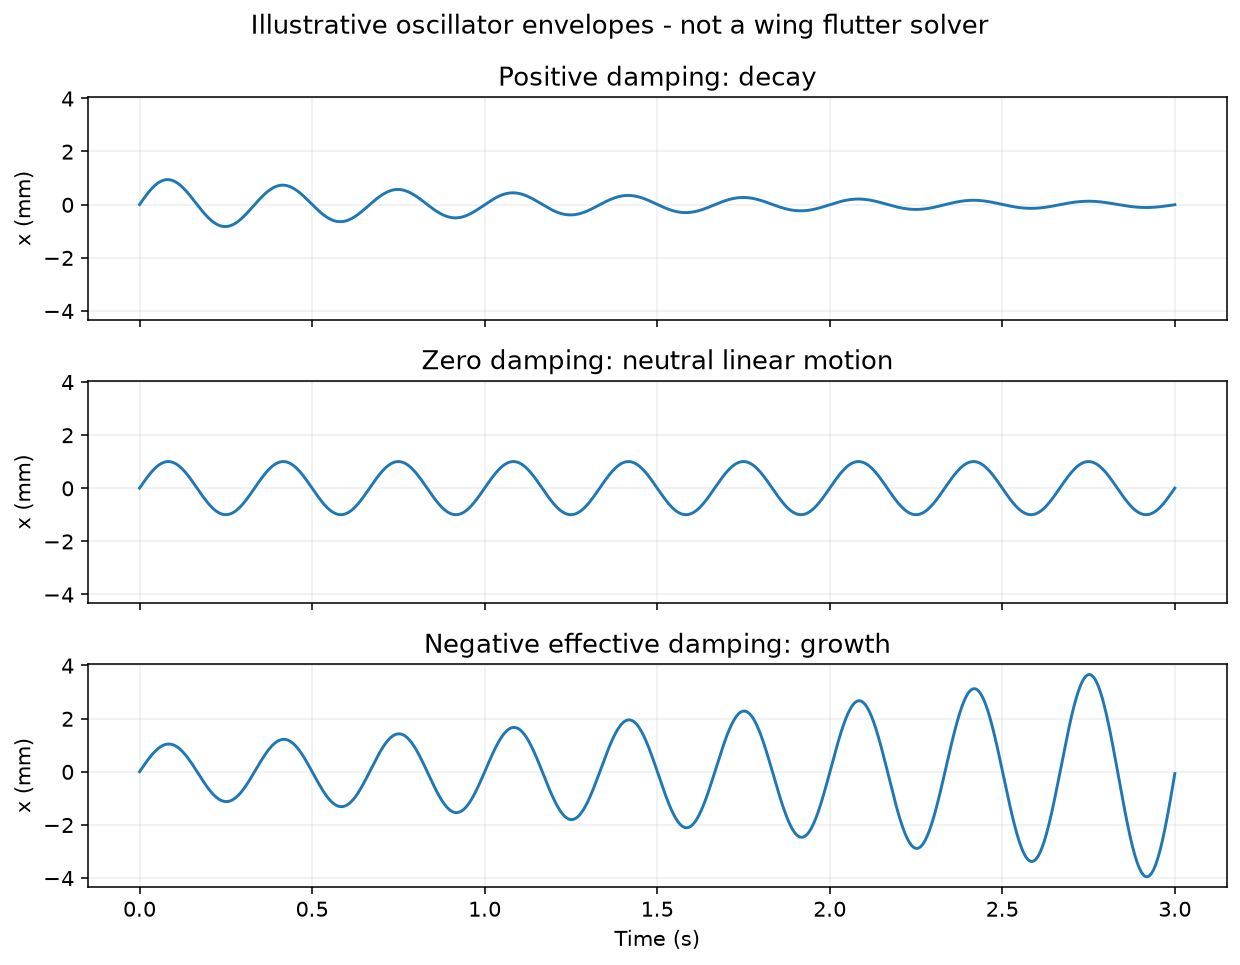

In [6]:
#@title Compare decay, neutral motion and growth - no real flutter-speed claim
FREQUENCY_HZ = 3.0 #@param {type:"number"}
INITIAL_SCALE_MM = 1.0 #@param {type:"number"}
assert FREQUENCY_HZ>0 and INITIAL_SCALE_MM>0
t=np.linspace(0,3,1500); wn=2*np.pi*FREQUENCY_HZ
fig,axes=plt.subplots(3,1,figsize=(9,7),sharex=True,sharey=True)
for ax,zeta,label in zip(axes,[.04,0.,-.025],['Positive damping: decay','Zero damping: neutral linear motion','Negative effective damping: growth']):
    wd=wn*np.sqrt(1-zeta*zeta)
    motion=INITIAL_SCALE_MM*np.exp(-zeta*wn*t)*np.sin(wd*t)
    ax.plot(t,motion);ax.set_title(label);ax.set_ylabel('x (mm)')
axes[-1].set_xlabel('Time (s)');fig.suptitle('Illustrative oscillator envelopes - not a wing flutter solver')
fig.tight_layout();plt.show()

## 10. A real structural failure sequence, and the limits of a numerical answer

In the 2005 Grumman Turbo Mallard accident, investigators identified pre-existing damage in a rear Z stringer, lower skin and rear lower spar cap. Fracture and cracking shifted loads into remaining members; declining residual strength eventually led to wing separation. This was an aircraft **with** those members, not one designed without them. [FAA case study, photographs and progressive-failure explanation](https://www.faa.gov/lessons_learned/transport_airplane/accidents/grumman-turbo-mallard-g-73t).

The example explains why inspection, damage tolerance, attachments and multiple load paths matter. It is not a controlled experiment proving that any missing stringer causes the same outcome.

| Question | Suitable first model | What that model cannot establish alone |
|---|---|---|
| Global wing bending/deflection | Beam or beam FEM with correct EI, loading and supports | Local skin/rib distortion, detailed joints, print defects |
| Thin skin compression stability | Plate/shell buckling screen | Ultimate collapse or damage tolerance without further analysis |
| Rib/bracing effectiveness | Compatible frame/shell and local member model | Benefit from rib count alone |
| Flutter | Coupled structural + unsteady aerodynamic stability analysis | A safe speed from static stress or a free-vibration plot alone |

**Do not confuse these events:** elastic deformation; yielding; local buckling; fatigue crack growth; fracture; static aeroelastic divergence; flutter. A real sequence can involve several, but evidence is needed to establish order and cause.

### Exit questions - answer in your own words

1. Under upward cantilever wing bending, which region is usually compressed? What happens under reversed load?
2. Why can removing a spar increase skin/joint demand even though the applied lift is unchanged?
3. What are the blue reference and red displacement curves in the rib side view? Are their numbers predictions for our printed wing?
4. What is the difference between rib spacing a and stringer spacing b?
5. Why are seven ribs a baseline construction choice rather than a universal requirement?
6. Which parts of the example spar are extruded, and which are sheet? Was 7-Shi's wing skin all metal?
7. Does higher tensile strength automatically raise EI or plate buckling stress?
8. How does aerodynamic phase affect work per cycle? Why can flutter occur below sonic speed?
9. Why must we distinguish a film scene from the 1940 Zero prototype accident?
10. Which result needs additional evidence before it can support a print release or structural-safety claim?

Use **Claim - Evidence - Check - Confidence - Limitation** for the final response. These exercises authorize numerical exploration only, not damage tests on student wings.

## Optional appendix A. Airfoil labels in the film are not structural specifications

The previously prepared comparison below is retained as context, not as a claim that either film label identifies every historical aircraft's wing. NACA M-series names are historical section identifiers, unlike the geometry encoding of the familiar four-digit series such as 2412.

The M12 contour shown is based on the [UIUC coordinate table](https://m-selig.ae.illinois.edu/ads/coord/m12.dat). The film-outline redraw is qualitative. The [UIUC data-site history](https://m-selig.ae.illinois.edu/ads_history.html) records problems with old M8/M9 coordinates; an unverified downloaded table is not sufficient to reconstruct the real M9 section. Film drawings, coordinate tables, aircraft adoption and original manufacturing drawings are four different kinds of evidence.

![Original explanatory comparison from our earlier discussion. The film outline is qualitative and not a hybrid-section specification; M12 coordinates do not prove adoption on 7-Shi, Ka-14 or Zero.](https://raw.githubusercontent.com/Ehsan-Roohi/Aerospace-Structures/main/docs/assets/wing-structure/Airfoils_The_Wind_Rises.png)

**Read the figure:** Original explanatory comparison from our earlier discussion. The film outline is qualitative and not a hybrid-section specification; M12 coordinates do not prove adoption on 7-Shi, Ka-14 or Zero.

## Sources and image credits

The historical discussion distinguishes original research, museum synthesis, designer accounts and film interpretation. The following links are for verification and further reading; no complete museum publication or film frame is republished here.

- [Yoshida, National Museum of Nature and Science: aluminium-alloy survey (English)](https://sts.kahaku.go.jp/albums/abm.php?d=6689&f=abm00010625.pdf&n=130_e.pdf), especially chapter 8, printed pp.77-82. English publication copyright 2025; original survey volume March 2022. Figure 8.4 is a source for the explanatory cap/web redraw, not a copied shop drawing.
- [Japanese edition](https://sts.kahaku.go.jp/albums/abm.php?d=6689&f=abm00010626.pdf&n=130.pdf).
- [Igarashi and Kitahara, 1939: ESD/ESDC properties](https://doi.org/10.14822/jjsass1934.6.53_982), pp.982-996.
- [Yoshida, 2023: ESD history and alloy tradeoffs](https://doi.org/10.2320/matertrans.MT-LA2022019).
- [UACJ manufacturer history](https://www.uacj.co.jp/english/company/history/story01.html).
- [NASA: effective widths of compression-loaded plates](https://ntrs.nasa.gov/citations/20000109795).
- [NASA archive: rib stiffness and wing-surface instability, 1962](https://ntrs.nasa.gov/citations/19630000940).
- [NASA: Wright wing model and geometry](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/wing-geometry/); [NPS: Chanute](https://www.nps.gov/people/chanute.htm).
- [Smithsonian: Zero engineering](https://airandspace.si.edu/stories/editorial/mitsubishi-a6m-zero-fighter).
- [FAA: Grumman Turbo Mallard load redistribution and fatigue](https://www.faa.gov/lessons_learned/transport_airplane/accidents/grumman-turbo-mallard-g-73t).
- [NASA: adaptive-wing tests and official video](https://www.nasa.gov/aeronautics/nasa-boeing-test-aircraft-wings/); [subsonic research benchmark](https://nescacademy.nasa.gov/workshops/AePW3/public/wg/largedeflection).
- [Studio Ghibli film record](https://www.ghibli.jp/works/kazetachinu/).

**Photograph provenance:** [7-Shi](https://commons.wikimedia.org/wiki/File:Mitsubishi_1MF10.jpg), [first Ka-14](https://commons.wikimedia.org/wiki/File:Kyushi_Tanza_Sentoki.jpg), [Horikoshi 1938](https://commons.wikimedia.org/wiki/File:Jiro_Horikoshi_193810.jpg): historical photographs, unknown photographers, Commons public-domain tags with original-source limitations retained. [Zero museum photograph](https://airandspace.si.edu/collection-media/NASM-A19600335000-NASM2018-10489-000001): Eric Long/Smithsonian, CC0. Wright model and adaptive-wing images: NASA source credits retained, no endorsement implied.

Original schematics are explanatory, not historical manufacturing drawings or certification analyses. The [asset provenance record](https://github.com/Ehsan-Roohi/Aerospace-Structures/blob/main/docs/assets/wing-structure/PHOTO_SOURCES.json) records image sources and rights. Low-resolution historical photographs are not artificially presented as detailed views of internal structure.

[Course home](https://github.com/Ehsan-Roohi/Aerospace-Structures) · [Printed-wing project](https://github.com/Ehsan-Roohi/Aerospace-Structures/blob/main/PROJECT.md) · [Wing Lab](https://ehsan-roohi.github.io/Aerospace-Structures/wing-lab.html)